# Exploratory Data Analysis on Census Data


Datasource link:

Statistics Canada. [Table 98-10-0129-01  Marital status, age group and gender: Canada, provinces and territories, census divisions, census subdivisions and dissemination areas.](https://www150.statcan.gc.ca/t1/tbl1/en/tv.action?pid=9810012901)

Frequency: Occasional

Table: 98-10-0129-01

Release Date: July 13, 2022

Geography: Canada, Province or Territory, Census Division, Census Subdivision, Dissemination Area

Universe: Population 15 years of age and older, 2021 Census — 100% Data

Description:

This dataset provides detailed information on marital status categorized by age group and gender for various geographic regions in Canada, including provinces, territories, census divisions, census subdivisions, and dissemination areas. The data is sourced from the 2021 Census, covering the entire population aged 15 years and older

In [1]:
import pandas as pd

df = pd.read_csv('../rawDataset/Barrie_population_demographics.csv')

In [2]:
df.head()

,REF_DATE,GEO,DGUID,Gender (3),Marital status (13),Age (16),UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,2021,Canada,2021A000011124,Total - Gender,Total - Marital status,Total - Age,NaN,0,units,0,NaN,1.1.1.1,30979185,NaN,NaN,NaN,0
1,2021,Canada,2021A000011124,Total - Gender,Total - Marital status,15 to 19 years,NaN,0,units,0,NaN,1.1.1.2,2012975,NaN,NaN,NaN,0
2,2021,Canada,2021A000011124,Total - Gender,Total - Marital status,20 to 24 years,NaN,0,units,0,NaN,1.1.1.3,2202260,NaN,NaN,NaN,0
3,2021,Canada,2021A000011124,Total - Gender,Total - Marital status,25 to 29 years,NaN,0,units,0,NaN,1.1.1.4,2421505,NaN,NaN,NaN,0
4,2021,Canada,2021A000011124,Total - Gender,Total - Marital status,30 to 34 years,NaN,0,units,0,NaN,1.1.1.5,2518830,NaN,NaN,NaN,0


In [18]:
columns_to_drop = ['VECTOR', 'COORDINATE','SCALAR_ID','SCALAR_FACTOR','UOM','UOM_ID','STATUS','SYMBOL','TERMINATED','DECIMALS']
df_cleaned = df.drop(columns=columns_to_drop)

print("Columns after dropping unwanted ones:")
print(df_cleaned.columns)

Columns after dropping unwanted ones:
Index(['REF_DATE', 'GEO', 'DGUID', 'Gender (3)', 'Marital status (13)',
       'Age (16)', 'VALUE'],
      dtype='object')


In [19]:
df_cleaned.shape

(24007, 7)

The shape (24007, 7) indicates that the census data, after removing specific columns, consists of 24,007 rows and 7 columns. The removed columns are:  

VECTOR  
COORDINATE  
SCALAR_ID  
SCALAR_FACTOR  
UOM  
UOM_ID  
STATUS  
SYMBOL  
TERMINATED  
DECIMALS  
After dropping these columns, the remaining dataset has 7 columns, which likely represent the key variables or features relevant for further analysis or modeling. The original dataset had additional columns that were not needed for the current analysis, so they were removed to simplify the dataset and focus on the most relevant information.  

In [20]:
columns_of_interest = ['REF_DATE', 'GEO', 'DGUID', 'Gender (3)', 'Marital status (13)', 'Age (16)']

# Function to get unique values for each column of interest
def get_unique_values(df, columns):
    unique_values = {}
    for column in columns:
        unique_values[column] = df[column].unique()
    return unique_values

# Get unique values for the specified columns
unique_values = get_unique_values(df, columns_of_interest)

# Print unique values for each column
for column, values in unique_values.items():
    print(f"Unique values for {column}:")
    print(values)
    print("\n")

Unique values for REF_DATE:
[2021]


Unique values for GEO:
['Canada' 'Barrie' '35430647' '35430648' '35430649' '35430650' '35430651'
 '35430652' '35430653' '35430654' '35430655' '35430656' '35430657'
 '35430658' '35430659' '35430660' '35430661' '35430662' '35430663'
 '35430664' '35430665' '35430666' '35430667' '35430668' '35430669'
 '35430670' '35430671' '35430672' '35430673' '35430674' '35430675'
 '35430676' '35430677' '35430678' '35430679' '35430680' '35430681'
 '35430682' '35430683' '35430684' '35430685' '35430686' '35430687'
 '35430688' '35430689' '35430690' '35430691' '35430693' '35430694'
 '35430696' '35430698' '35430699' '35430700' '35430701' '35430702'
 '35430703' '35430704' '35430705' '35430706' '35430707' '35430708'
 '35430709' '35430710' '35430711' '35430712' '35430713' '35430714'
 '35430988' '35430989' '35430992' '35430993' '35430994' '35430995'
 '35430996' '35430997' '35430998' '35430999' '35431000' '35431001'
 '35431002' '35431003' '35431004' '35431005' '35431006' '35431

In [21]:
df_cleaned = df_cleaned.drop('Gender (3)', axis=1)

The 'Gender (3)' column contains a single unique value: 'Total - Gender'. This means that the column does not provide detailed gender information but instead summarizes the data for all genders combined.
Therefore, this column is being removed from the dataset as it does not provide any specific gender information, simplifying the analysis.

In [22]:
df_cleaned.head()

,REF_DATE,GEO,DGUID,Marital status (13),Age (16),VALUE
0,2021,Canada,2021A000011124,Total - Marital status,Total - Age,30979185
1,2021,Canada,2021A000011124,Total - Marital status,15 to 19 years,2012975
2,2021,Canada,2021A000011124,Total - Marital status,20 to 24 years,2202260
3,2021,Canada,2021A000011124,Total - Marital status,25 to 29 years,2421505
4,2021,Canada,2021A000011124,Total - Marital status,30 to 34 years,2518830


In [23]:
df_cleaned = df_cleaned[df_cleaned['GEO'] != 'Canada']

print("DataFrame after removing rows where GEO equals 'Canada':")
print(df_cleaned.head())

DataFrame after removing rows where GEO equals 'Canada':
     REF_DATE     GEO             DGUID     Marital status (13)  \
205      2021  Barrie  2021A00053543042  Total - Marital status   
206      2021  Barrie  2021A00053543042  Total - Marital status   
207      2021  Barrie  2021A00053543042  Total - Marital status   
208      2021  Barrie  2021A00053543042  Total - Marital status   
209      2021  Barrie  2021A00053543042  Total - Marital status   

           Age (16)   VALUE  
205     Total - Age  123085  
206  15 to 19 years    9090  
207  20 to 24 years   10050  
208  25 to 29 years   10765  
209  30 to 34 years   10810  


In [24]:
df_cleaned = df_cleaned[df_cleaned['GEO'] != 'Barrie']

In [27]:
df_cleaned.head()

,REF_DATE,GEO,DGUID,Marital status (13),Age (16),VALUE
402,2021,35430647,2021S051235430647,Total - Marital status,Total - Age,685
403,2021,35430647,2021S051235430647,Total - Marital status,15 to 19 years,50
404,2021,35430647,2021S051235430647,Total - Marital status,20 to 24 years,55
405,2021,35430647,2021S051235430647,Total - Marital status,25 to 29 years,45
406,2021,35430647,2021S051235430647,Total - Marital status,30 to 34 years,80


Removing rows corresponding to Canada and Barrie location data because the focus is solely on population data by Dissemination area.

### Severity Indicator- Percentage of population 65 years and over Calculation

In [29]:
age_groups = [
    '65 to 69 years',
    '70 to 74 years',
    '75 to 79 years',
    '80 to 84 years',
    '85 years and over'
]

# Filter the DataFrame for the specified age groups and where marital status is "Total - Marital status"
df_filtered = df_cleaned[(df_cleaned['Age (16)'].isin(age_groups)) & (df_cleaned['Marital status (13)'] == 'Total - Marital status')]

# Group by 'GEO' and sum the 'VALUE' for each group
df_grouped = df_filtered.groupby('GEO')['VALUE'].sum().reset_index()
df_grouped.rename(columns={'GEO': 'DAUID', 'VALUE': 'population_count_above_aged_65'}, inplace=True)

# Get the total population for each GEO where Age is "Total - Age" and marital status is "Total - Marital status"
total_population_df = df_cleaned[(df_cleaned['Age (16)'] == 'Total - Age') & (df_cleaned['Marital status (13)'] == 'Total - Marital status')][['GEO', 'VALUE']]
total_population_df.rename(columns={'GEO': 'DAUID', 'VALUE': 'total_population'}, inplace=True)

# Merge the dataframes
result_df = pd.merge(df_grouped, total_population_df, on='DAUID')

# Calculate the percentage of the population aged above 65
result_df['percentage_above_aged_65'] = (result_df['population_count_above_aged_65'] / result_df['total_population']) * 100

# Round the percentage to 2 decimal places
result_df['percentage_above_aged_65'] = result_df['percentage_above_aged_65'].round(2)

# Display the result
print("Sum of values for above 65 age groups for each GEO:")
print(result_df)

# Save the result to a CSV file
result_df.to_csv('../Cleaned_dataset/Population_aged_above_65.csv', index=False)

print("Data saved to ../Cleaned_dataset/Population_aged_above_65.csv")

Sum of values for above 65 age groups for each GEO:
        DAUID  population_count_above_aged_65  total_population  \
0    35430647                             105               685   
1    35430648                              60               440   
2    35430649                              60               355   
3    35430650                             110               515   
4    35430651                              55               355   
..        ...                             ...               ...   
238  35431370                              80               880   
239  35431371                              60               520   
240  35431372                              50               295   
241  35431373                              75               270   
242  35431380                              75               745   

     percentage_above_aged_65  
0                       15.33  
1                       13.64  
2                       16.90  
3              

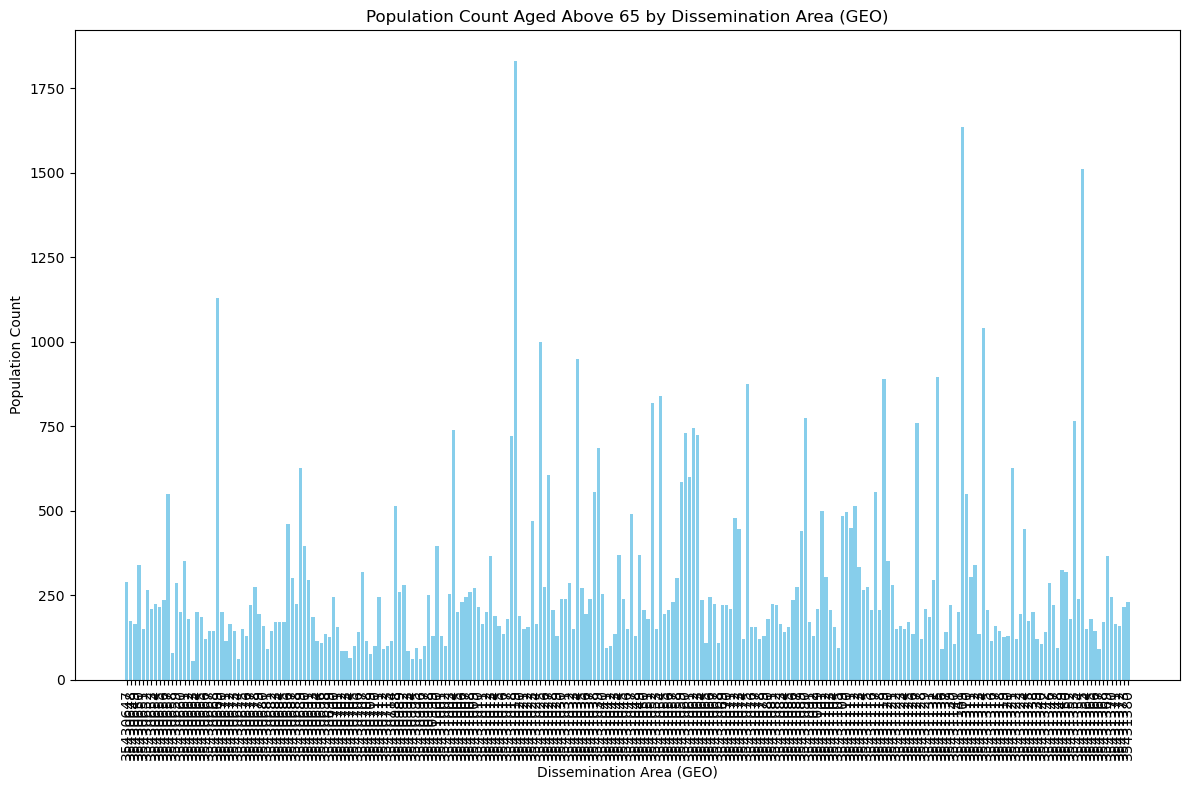

In [32]:

import matplotlib.pyplot as plt

# Plotting the results
plt.figure(figsize=(12, 8))
plt.bar(df_grouped['GEO'], df_grouped['VALUE'], color='skyblue')

# Adding titles and labels
plt.title('Population Count Aged Above 65 by Dissemination Area (GEO)')
plt.xlabel('Dissemination Area (GEO)')
plt.ylabel('Population Count')
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability

# Display the graph
plt.tight_layout()
plt.show()

Top 10 dissemination areas with highest population counts (aged above 65):
          GEO  VALUE
94   35431019   1830
202  35431309   1635
231  35431355   1510
22   35430669   1130
207  35431314   1040
100  35431025   1000
109  35431034    950
196  35431135    895
183  35431119    890
150  35431075    875


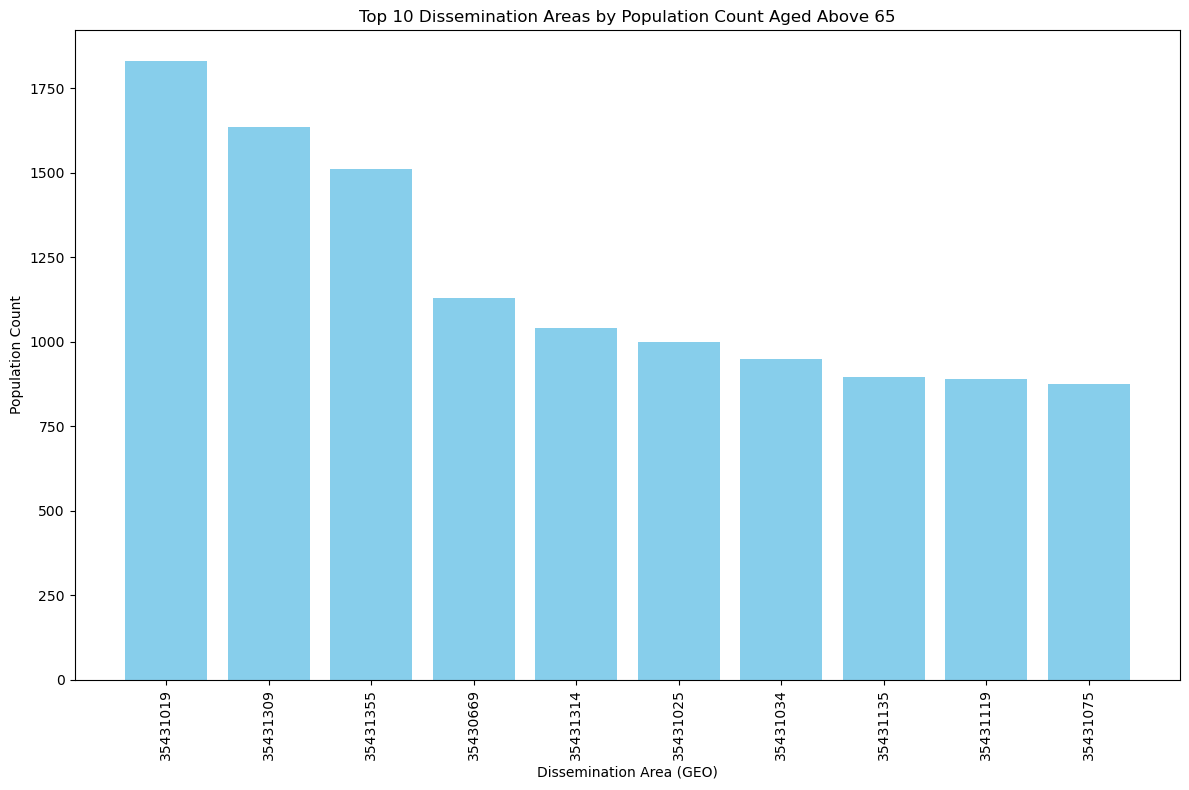

In [39]:
# Sort the grouped DataFrame by the summed values in descending order
df_sorted = df_grouped.sort_values(by='VALUE', ascending=False)

# Select the top 10 rows
df_top_10 = df_sorted.head(10)

# Display the top 10 dissemination areas with highest population counts
print("Top 10 dissemination areas with highest population counts (aged above 65):")
print(df_top_10)

# Plotting the results
plt.figure(figsize=(12, 8))
plt.bar(df_top_10['GEO'], df_top_10['VALUE'], color='skyblue')

# Adding titles and labels
plt.title('Top 10 Dissemination Areas by Population Count Aged Above 65')
plt.xlabel('Dissemination Area (GEO)')
plt.ylabel('Population Count')
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability

# Display the graph
plt.tight_layout()
plt.show()